In [1]:
!pip install ydata-profiling
import pandas as pd
from ydata_profiling import ProfileReport
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.3 MB/s eta 0:00:00


/tmp/ipykernel_1854/2687086356.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## 1. Load Data

In [2]:
customer_df = pd.read_csv("/content/UK-Bank-Customers.csv")

## 2. Data Overview

In [ ]:
print(f"Number of Rows: {customer_df.shape[0]}")
print(f"Number of Columns : {customer_df.shape[1]}")
print(f"Head :\n{customer_df.head()}")

Number of Rows: 4014
Number of Columns : 9
Head :
   Customer ID     Name  Surname  Gender  Age            Region  \
0    100000001    Simon    Walsh    Male   21           England   
1    400000002  Jasmine   Miller  Female   34  Northern Ireland   
2    100000003     Liam    Brown    Male   46           England   
3    300000004   Trevor     Parr    Male   32             Wales   
4    100000005  Deirdre  Pullman  Female   38           England   

  Job Classification Date Joined    Balance  
0       White Collar   05.Jan.15  113810.15  
1        Blue Collar   06.Jan.15   36919.73  
2       White Collar   07.Jan.15  101536.83  
3       White Collar   08.Jan.15    1421.52  
4        Blue Collar   09.Jan.15   35639.79  


In [ ]:
print(customer_df.info())
print(f"Describe:\n{customer_df.describe()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4014 entries, 0 to 4013
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer ID         4014 non-null   int64  
 1   Name                4014 non-null   object 
 2   Surname             4014 non-null   object 
 3   Gender              4014 non-null   object 
 4   Age                 4014 non-null   int64  
 5   Region              4014 non-null   object 
 6   Job Classification  4014 non-null   object 
 7   Date Joined         4014 non-null   object 
 8   Balance             4014 non-null   float64
dtypes: float64(1), int64(2), object(6)
memory usage: 282.4+ KB
None
Describe:
        Customer ID          Age        Balance
count  4.014000e+03  4014.000000    4014.000000
mean   1.696831e+08    38.611111   39766.448274
std    8.865374e+07     9.819121   29859.489192
min    1.000000e+08    15.000000      11.520000
25%    1.000020e+08    31.000000   1

In [ ]:
print(f"Columns Name :\n {customer_df.columns.to_list()}")

Columns Name :
 ['Customer ID', 'Name', 'Surname', 'Gender', 'Age', 'Region', 'Job Classification', 'Date Joined', 'Balance']


In [ ]:
profile = ProfileReport(customer_df, title='UK Bank Customers Profiling Report')

In [ ]:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 58.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

##3. Data Cleaning

In [3]:
missing_values = customer_df.isnull().sum()
missing_percentage = (missing_values / len(customer_df)) * 100
missing_report = pd.DataFrame({"Missing Count" : missing_values, "Missing Percentage" : missing_percentage})
print(f'Missing Report:\n{missing_report.sort_values(by="Missing Percentage")}')

Missing Report:
                    Missing Count  Missing Percentage
Customer ID                     0                 0.0
Name                            0                 0.0
Surname                         0                 0.0
Gender                          0                 0.0
Age                             0                 0.0
Region                          0                 0.0
Job Classification              0                 0.0
Date Joined                     0                 0.0
Balance                         0                 0.0


In [4]:
customer_df.duplicated().sum()

np.int64(0)

In [5]:
customer_df["Age"].between(18,100).all()

np.False_

0      2015-01-05
1      2015-01-06
2      2015-01-07
3      2015-01-08
4      2015-01-09
          ...    
4009   2015-12-30
4010   2015-12-30
4011   2015-12-30
4012   2015-12-30
4013   2015-12-30
Name: Date Joined, Length: 4014, dtype: datetime64[ns]
   Age    Balance
0   21  113810.15
1   34   36919.73
2   46  101536.83
3   32    1421.52
4   38   35639.79
  Date Joined
0  2015-01-05
1  2015-01-06
2  2015-01-07
3  2015-01-08
4  2015-01-09
   Customer ID     Name  Surname  Gender            Region Job Classification
0    100000001    Simon    Walsh    Male           England       White Collar
1    400000002  Jasmine   Miller  Female  Northern Ireland        Blue Collar
2    100000003     Liam    Brown    Male           England       White Collar
3    300000004   Trevor     Parr    Male             Wales       White Collar
4    100000005  Deirdre  Pullman  Female           England        Blue Collar


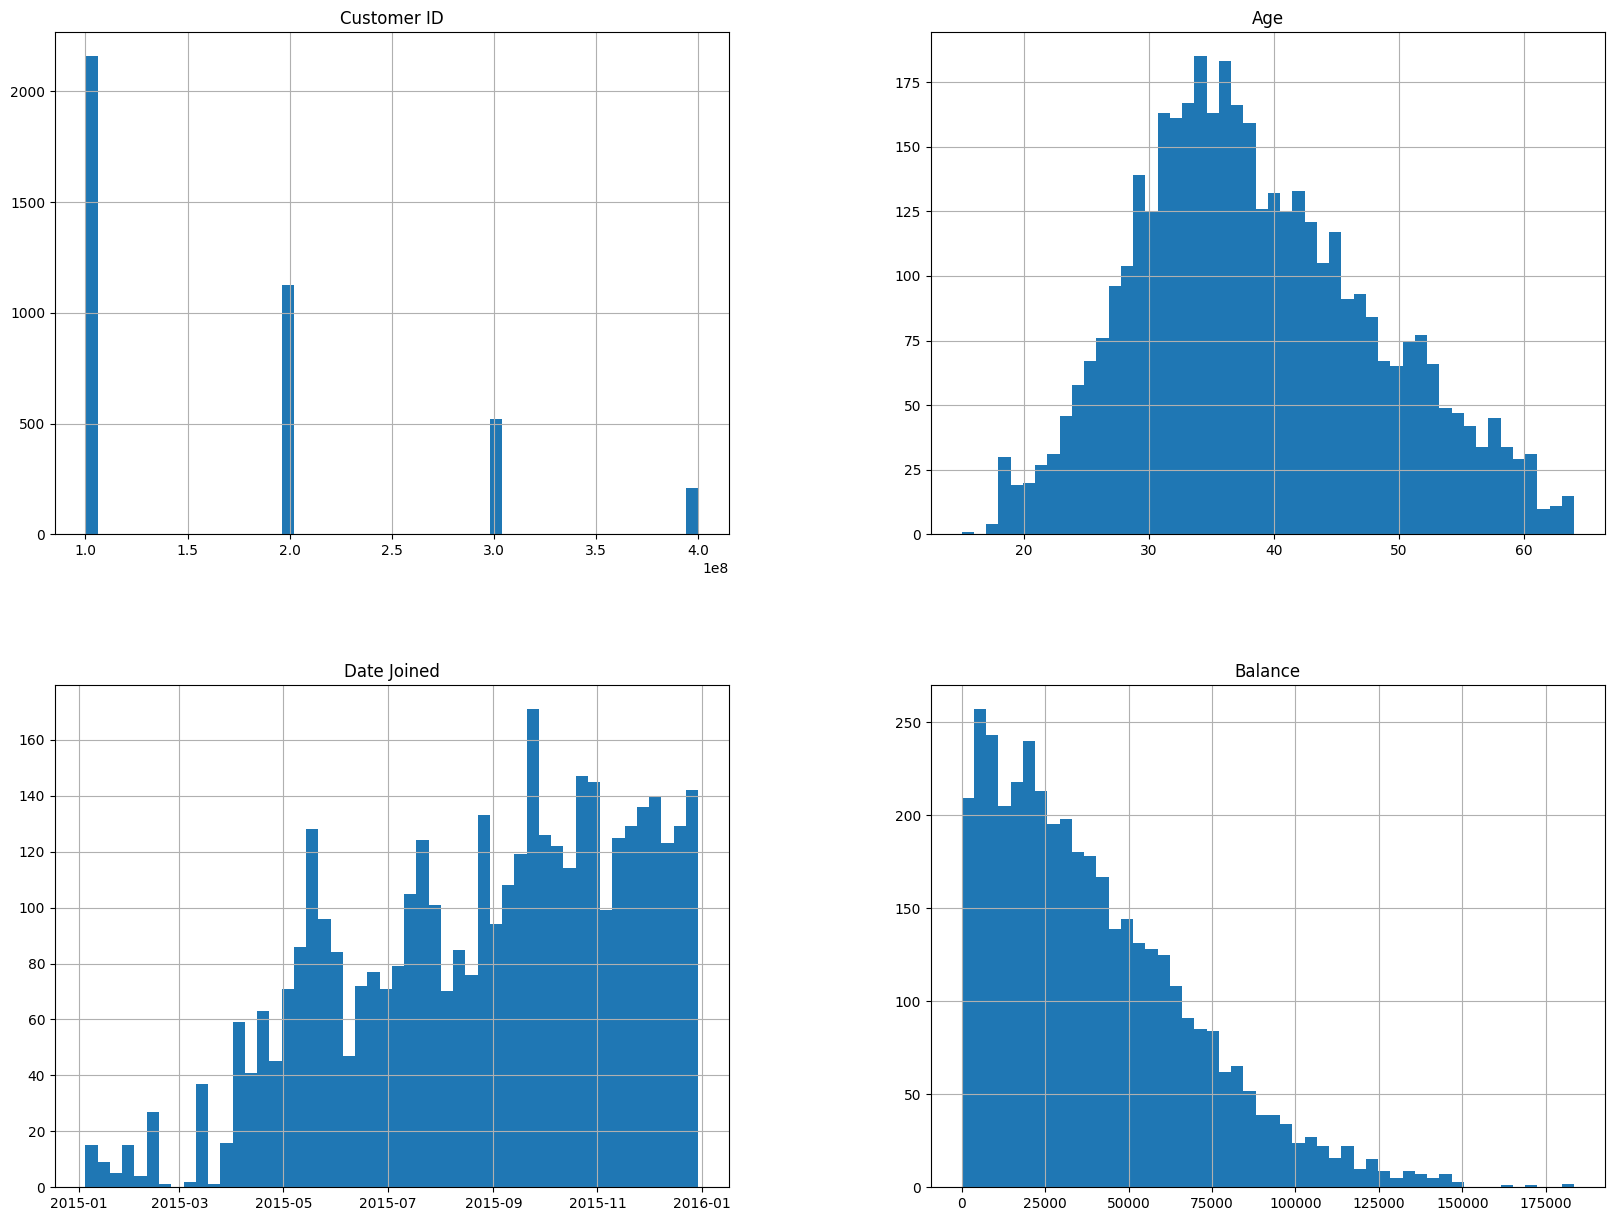

In [6]:
# Convert Date Joined Column to Datetime
customer_df["Date Joined"] = pd.to_datetime(customer_df["Date Joined"], format = "%d.%b.%y" )
print(customer_df["Date Joined"])

# Select Numerical,  Categorical, Date Time

#Numerical
customer_df_num = customer_df[["Age", "Balance"]]
print(customer_df_num.head())

#Time
customer_df_time = customer_df[["Date Joined"]]
print(customer_df_time.head())

#Categorical
customer_df_cat = customer_df.drop(["Age", "Balance", "Date Joined"], axis=1)
print(customer_df_cat.head())

customer_df.hist(bins=50,figsize=(20, 15))
plt.show()


In [7]:
#Describe Statistics of Numerical Values

for index in range(len(customer_df_num.columns)):
     col = customer_df_num.columns[index]
     print(f'Describe of {col} :\n{customer_df_num[col].describe()}')

customer_df["Join_Month"] = customer_df["Date Joined"].dt.month
print(f"Join Month:\n {customer_df['Join_Month'].head()}")

customer_df["Join_Quarter"] = customer_df["Date Joined"].dt.quarter
print(f"Join Quarter:\n {customer_df['Join_Quarter'].head()}")

print(f"First Join Date:\n {customer_df['Date Joined'].min()}")
print(f"Last Join Date:\n {customer_df['Date Joined'].max()}")


Describe of Age :
count    4014.000000
mean       38.611111
std         9.819121
min        15.000000
25%        31.000000
50%        37.000000
75%        45.000000
max        64.000000
Name: Age, dtype: float64
Describe of Balance :
count      4014.000000
mean      39766.448274
std       29859.489192
min          11.520000
25%       16115.367500
50%       33567.330000
75%       57533.930000
max      183467.700000
Name: Balance, dtype: float64
Join Month:
 0    1
1    1
2    1
3    1
4    1
Name: Join_Month, dtype: int32
Join Quarter:
 0    1
1    1
2    1
3    1
4    1
Name: Join_Quarter, dtype: int32
First Join Date:
 2015-01-05 00:00:00
Last Join Date:
 2015-12-30 00:00:00


In [8]:
# Outlier Detection
Q1_age = customer_df["Age"].quantile(0.25)
Q3_age = customer_df["Age"].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = IQR_age - 1.5*IQR_age
upper_age = IQR_age + 1.5*IQR_age

age_outliers = customer_df [
    (customer_df["Age"] < lower_age) |
    (customer_df["Age"] > upper_age)
]

age_outliers_percentage = (
    len(age_outliers) / len(customer_df)
)*100

print(f"Number of Age Outliers: \n{len(age_outliers)}")
print(f"Age Outliers: \n {age_outliers_percentage}")

Q1_balance = customer_df["Balance"].quantile(0.25)
Q3_balance = customer_df["Balance"].quantile(0.75)

IQR_balance = Q3_balance - Q1_balance

lower_balance = IQR_balance - 1.5*IQR_balance
upper_balance = IQR_balance + 1.5*IQR_balance

balance_outliers = customer_df [
    (customer_df["Balance"] < lower_balance) |
    (customer_df["Balance"] > upper_balance)
]

balance_outliers_percentage = (
    len(balance_outliers) / len(customer_df)
)*100


print(f"Number of Balance Outliers: \n{len(balance_outliers)}")
print(f"Balance Outliers: \n {balance_outliers_percentage}")

Number of Age Outliers: 
2332
Age Outliers: 
 58.096661684105634
Number of Balance Outliers: 
159
Balance Outliers: 
 3.961136023916293


##4. Feature Engineering

In [9]:

#Classification Age
def age_group(age):
     if age<= 24:
          return "18-24"
     elif 24<age<=44:
          return "25-44"
     elif 44<age<=59:
          return "45-59"
     else :
          return "+60"

customer_df["Age_Group"] = customer_df["Age"].apply(age_group)

counts_gender_cls_age = customer_df.groupby(["Age_Group", "Gender"]).size().reset_index(name="Count")

order_age_clf = ["18-24", "25-44", "45-59", "+60"]
counts_gender_cls_age["Age_Group"]= pd.Categorical(counts_gender_cls_age["Age_Group"], categories=order_age_clf, ordered=True)

new_featueres = ["Age_Group", "Join_Month", "Join_Quarter"]
print(customer_df[new_featueres].head(10))


  Age_Group  Join_Month  Join_Quarter
0     18-24           1             1
1     25-44           1             1
2     45-59           1             1
3     25-44           1             1
4     25-44           1             1
5     25-44           1             1
6     25-44           1             1
7     45-59           1             1
8     25-44           1             1
9     25-44           1             1


In [10]:
median_blnc_by_age = customer_df.groupby("Age_Group")["Balance"].median().reset_index()
print(f'Median Balance by Age:\n{median_blnc_by_age}')

Median Balance by Age:
  Age_Group    Balance
0       +60  32180.145
1     18-24  32303.760
2     25-44  33324.090
3     45-59  34880.570


In [11]:
job_region_blnc = customer_df.groupby(["Job Classification", "Region"])["Balance"].median().unstack()
print(job_region_blnc)

Region                England  Northern Ireland   Scotland      Wales
Job Classification                                                   
Blue Collar         33019.225          33551.51  33252.005  37745.325
Other               36688.300          32458.74  35185.530  34170.610
White Collar        31681.140          34075.29  34230.155  36638.210


In [12]:
join_by_month =pd.DataFrame(customer_df['Date Joined'].dt.month).value_counts().sort_index().reset_index()
join_by_month.columns = ['Date Joined', 'Customer Count']
join_by_month['Month Name'] = join_by_month['Date Joined'].apply(lambda x: calendar.month_name[x])

In [13]:
region_count = customer_df['Region'].value_counts().reset_index()
region_count.columns = ['Region Name', 'Region Count']

In [14]:
blnc_by_job = customer_df.groupby('Job Classification')['Balance'].agg(['mean', 'std', 'median', 'count', 'min', 'max']).reset_index()
print(blnc_by_job)


  Job Classification          mean           std    median  count     min  \
0        Blue Collar  39403.294090  30070.537635  33570.99   1049   69.01   
1              Other  39824.341416  28850.161430  35266.30   1010  133.75   
2       White Collar  39931.397974  30269.082352  32658.92   1955   11.52   

         max  
0  161517.82  
1  172085.48  
2  183467.70  


In [15]:
region_blnc = customer_df.groupby('Region')['Balance'].agg(
    Mean_Balance = 'mean',
    Std_Balance = 'std',
    Median_balance = 'median',
    Count ='count',
    Min = 'min',
    Max = 'max' ).reset_index()
print(region_blnc)

             Region  Mean_Balance   Std_Balance  Median_balance  Count    Min  \
0           England  39292.911996  30011.228580        32529.22   2159  11.52   
1  Northern Ireland  39505.053981  31162.984319        33024.70    211  21.03   
2          Scotland  39511.326263  28955.962993        34494.43   1124  69.01   
3             Wales  42390.056269  30557.673305        36714.39    520  77.46   

         Max  
0  183467.70  
1  149698.12  
2  172085.48  
3  145995.97  


## 5. Exploratory Data Analysis (EDA)

In [23]:
custom_palette = ['#003049', '#669BBC', '#D6CCC2', '#9E9E9E', '#1E88E5']
main_text = '#003049'
primary_bar = '#669BBC'
secondary_highlight = '#D6CCC2'
background = '#9E9E9E'
accent_line = '#1E88E5'

sns.set_theme(
    context="talk",
    style="darkgrid",
    palette=custom_palette
)

figsize = (10,5)

plt.rcParams.update({
     "figure.figsize": (10,5),
     "axes.titlesize": 16,
     "axes.titleweight": "bold",
     "axes.labelsize": 14,
     "axes.labelweight": "bold",
     "xtick.labelsize": 12,
     "ytick.labelsize": 12,
     "legend.fontsize": 12,
     "legend.title_fontsize": 13,
     "font.family": "DejaVu Sans",
     "axes.spines.top": False,
     "axes.spines.right": False
})

## 5.1 Median Balance by Age Clasification

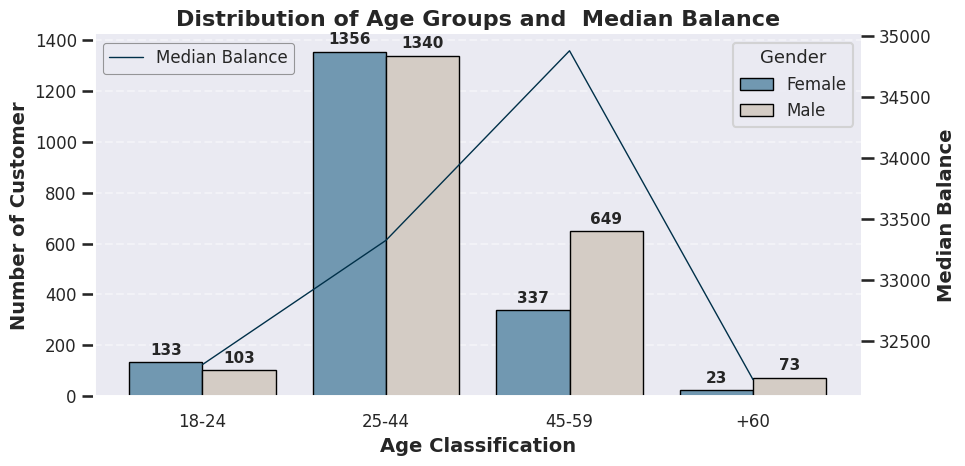

In [ ]:
fig, ax = plt.subplots(figsize= figsize)

sns.barplot(
     data=counts_gender_cls_age,
     x="Age_Group",
     y="Count",
     hue="Gender",
     palette=[custom_palette[1], custom_palette[2]],
     ax=ax,
     edgecolor="black",
     linewidth=1.0

     )

for container in ax.containers:
     ax.bar_label(container, fmt="%d", label_type="edge", padding=3, fontsize=11, fontweight="bold")

ax.set_xlabel("Age Classification")
ax.set_ylabel("Number of Customer")
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', visible=False)
leg = ax.legend(
    title="Gender",
    frameon=True,
    fancybox=True,
    shadow=False,
    loc="upper right"
)


ax2 = ax.twinx()
sns.lineplot(
     data= median_blnc_by_age,
     x= "Age_Group",
     y= "Balance",
     ax= ax2,
     color= custom_palette[0],
     markers= "o",
     linewidth= 1,
     label= "Median Balance"
)

ax2.set_ylabel("Median Balance")
ax2.grid(False)
leg = ax2.legend(
    frameon=True,
    fancybox=True,
    shadow=False,
    loc="upper left"
)

plt.title("Distribution of Age Groups and  Median Balance")
leg.get_frame().set_edgecolor("gray")
leg.get_frame().set_linewidth(0.8)
plt.tight_layout()
plt.show()

print(f"")

Insight :
The majority of customers belong to the 25–44 age group, making it the largest customer segment for the bank across both genders.
The 45–59 age group has fewer customers compared to the 25–44 group, but it shows a higher median account balance, indicating greater financial value per customer.
Customers aged 60+ have the highest median balance, despite representing the smallest customer segment, suggesting that older customers tend to maintain higher account balances.
The customer distribution between males and females is relatively balanced in most age groups, with a slightly higher number of male customers in the older age groups.

## 5.2 Balance Distribution by Job Classifiacation

/tmp/ipykernel_2991/4161323987.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_2991/4161323987.py:3: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  ax = sns.boxplot(


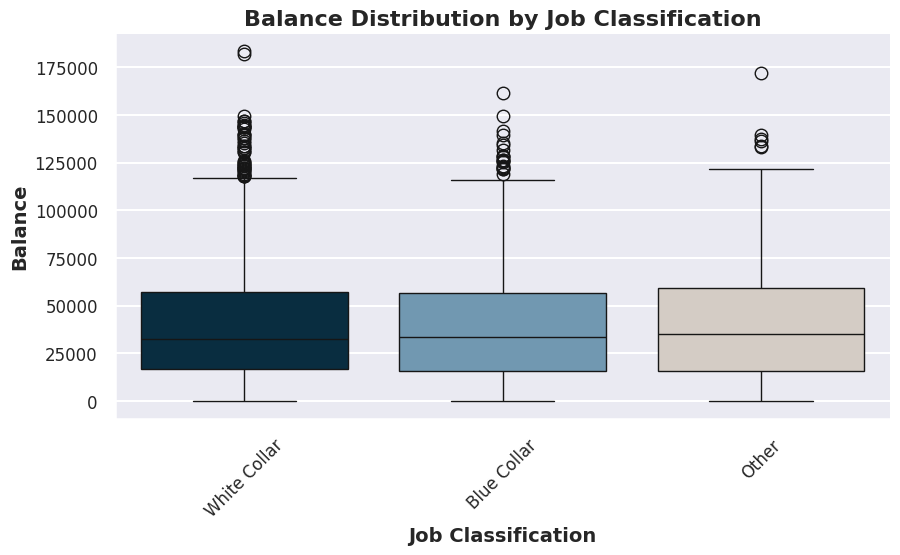

In [ ]:
plt.figure(figsize= figsize)

ax = sns.boxplot(
    data = customer_df,
    x = "Job Classification" ,
    y = "Balance",
    palette = custom_palette
    )

plt.title("Balance Distribution by Job Classification")
plt.xlabel("Job Classification")
plt.ylabel("Balance")
plt.xticks(rotation=45)

plt.show()

Insight :
The distribution of account balances is relatively similar across all job classifications, with no major difference in median balance between White Collar, Blue Collar, and Other customers.
Customers in the Other job classification show a slightly higher median balance compared to the other groups, indicating a potentially higher average financial position.
All job classifications contain a considerable number of high-balance outliers, suggesting that a small group of customers maintain significantly larger account balances regardless of their job category.
The large spread and presence of outliers indicate that job classification alone may not be a strong factor for explaining customer account balance variations.

## 5.3 Balance Distribution by Region

/tmp/ipykernel_2991/2884308655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_2991/2884308655.py:3: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.boxplot(


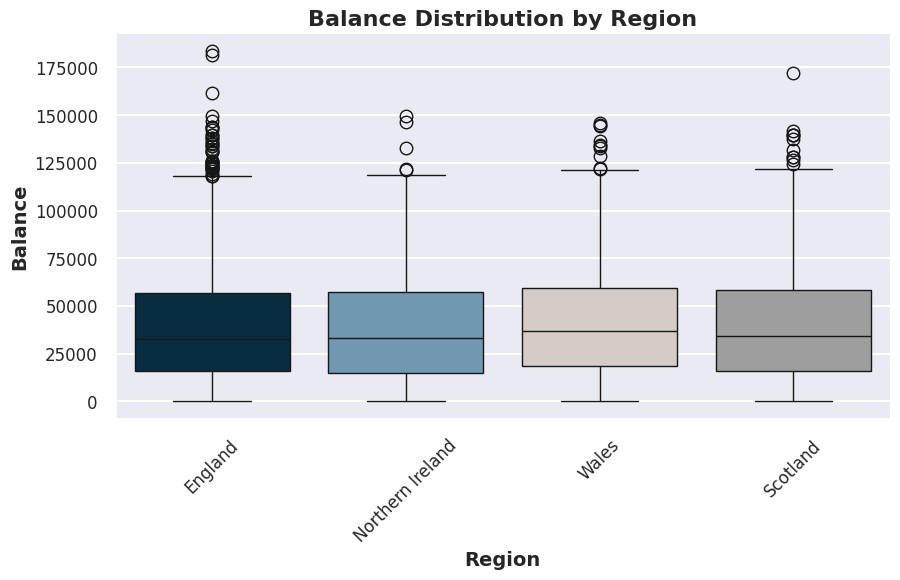

In [ ]:
plt.figure(figsize= figsize)

ax = sns.boxplot(
    data = customer_df,
    x = "Region" ,
    y = "Balance",
    palette = custom_palette
    )

plt.title("Balance Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Balance")
plt.xticks(rotation=45)

plt.show()

Insight :
The median account balance is relatively similar across all regions, indicating no substantial regional differences in customer balances.
Customers from Wales appear to have a slightly higher median balance compared to the other regions.
All regions exhibit a wide spread of account balances and contain several high-value outliers, suggesting that high-balance customers are present throughout the UK.
The similarity in balance distributions implies that region alone is unlikely to be a strong predictor of customer account balance.

## 5.4 Balance Distribution by Age Group

/tmp/ipykernel_2991/2943933758.py:2: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(


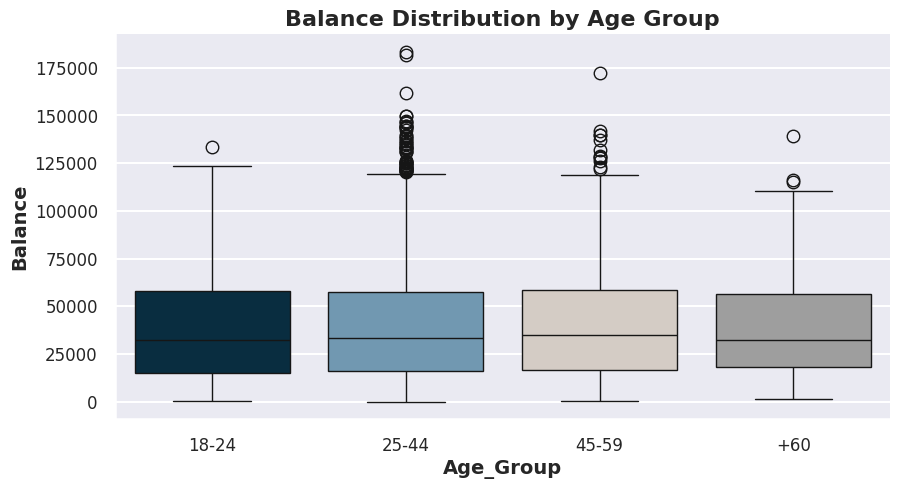

In [ ]:
plt.figure(figsize=figsize)
sns.boxplot(
     data= customer_df,
     x = "Age_Group",
     y = "Balance",
     order = order_age_clf,
     palette = custom_palette,
     hue = "Age_Group",
     legend = False
)

plt.title("Balance Distribution by Age Group")
plt.show()

Insight: The median account balance generally increases from the younger age groups to the 45–59 age group, indicating that older customers tend to maintain higher account balances.
The 45–59 and 60+ age groups exhibit a wider spread in account balances, suggesting greater variability in customers' financial status.
High-balance outliers are present across all age groups, indicating that customers with exceptionally large account balances exist regardless of age.
Although younger customers (18–24) have lower median balances, some individuals still maintain significantly high account balances.

## 5.5 Median Balance by Job Classification and Region




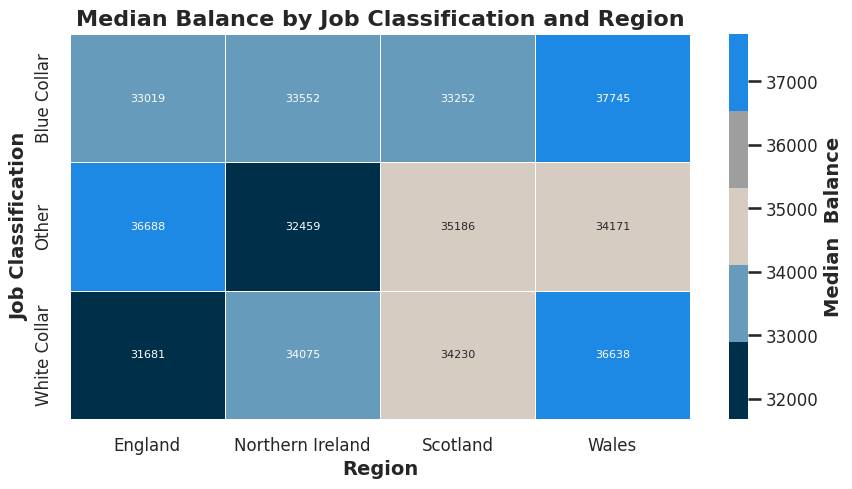

In [19]:
plt.figure(figsize= figsize)
sns.heatmap(
     data = job_region_blnc,
    annot=True,
    fmt=".0f",
    annot_kws={"size":8},
    cbar_kws={"label": "Median  Balance"},
    cmap=custom_palette,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Median Balance by Job Classification and Region")
plt.show()


Insight : Median account balances vary moderately across different combinations of job classification and region.
Wales has the highest median balance for both Blue Collar and White Collar customers.
Among customers classified as Other, England records the highest median balance.
No single region consistently has the highest median balance across all job classifications, suggesting that customer balance patterns are influenced by the combination of both region and job classification rather than either factor alone.

## 5.6 Join Month Analysis

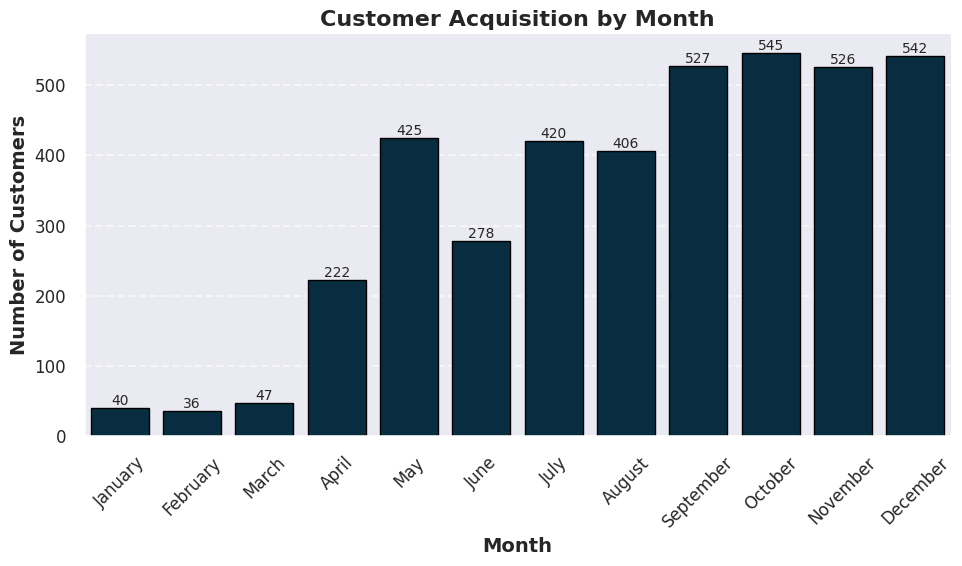

In [28]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
     data = join_by_month,
     x = "Month Name",
     y = "Customer Count",
     color = custom_palette[0],
     edgecolor="black",
     linewidth=1.0
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Customer Acquisition by Month")
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: Customer acquisition shows an overall increasing trend throughout the year.
The first quarter (January to March) records the lowest number of new customers.
Customer acquisition begins to increase from April and reaches its highest levels during the final quarter of the year.
October and December have the highest customer acquisition, suggesting that customer onboarding activity is stronger toward the end of the year.
The observed pattern may indicate seasonal effects or the impact of marketing campaigns; however, additional business information would be required to determine the exact cause.

## 5.7 Region analysis

/tmp/ipykernel_1854/2950876732.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_1854/2950876732.py:5: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.barplot(


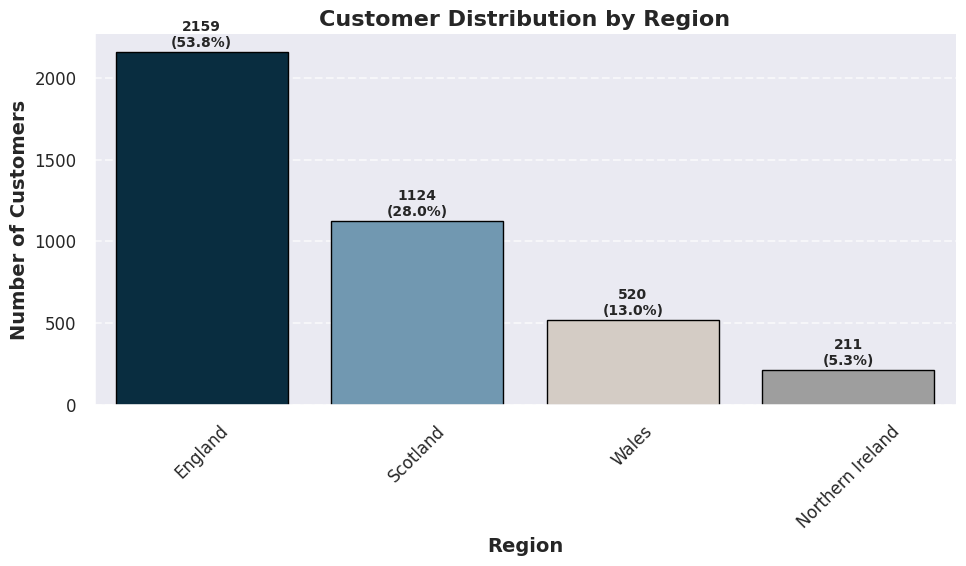

In [35]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data = region_count,
    x = 'Region Name',
    y = 'Region Count',
    palette = custom_palette,
    edgecolor="black",
    linewidth=1.0
)
for i, row  in region_count.iterrows():
    ax.text(
        i,
        row["Region Count"] + 30,
        f'{row["Region Count"]}\n({row["Percentage"]}%)',
        ha="center",
        fontsize=10,
        fontweight="bold"
    )
plt.title("Customer Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: England represents the largest customer base, accounting for 53.8% of all customers (2,159 customers), indicating that the bank's operations are heavily concentrated in this region.
Scotland is the second-largest market with 28.0% of customers, while Wales (13.0%) and Northern Ireland (5.3%) contribute considerably smaller shares.
The customer distribution is uneven across regions, suggesting that the bank has a stronger market presence in England than in the other UK regions.
The relatively small customer bases in Wales and Northern Ireland may indicate potential opportunities for future customer acquisition and regional expansion.